>>> 已加载 1000 个原始模式
原始标准差 (Raw Sigma): 0.8219
解折叠后标准差 (Unfolded Sigma): 0.8233


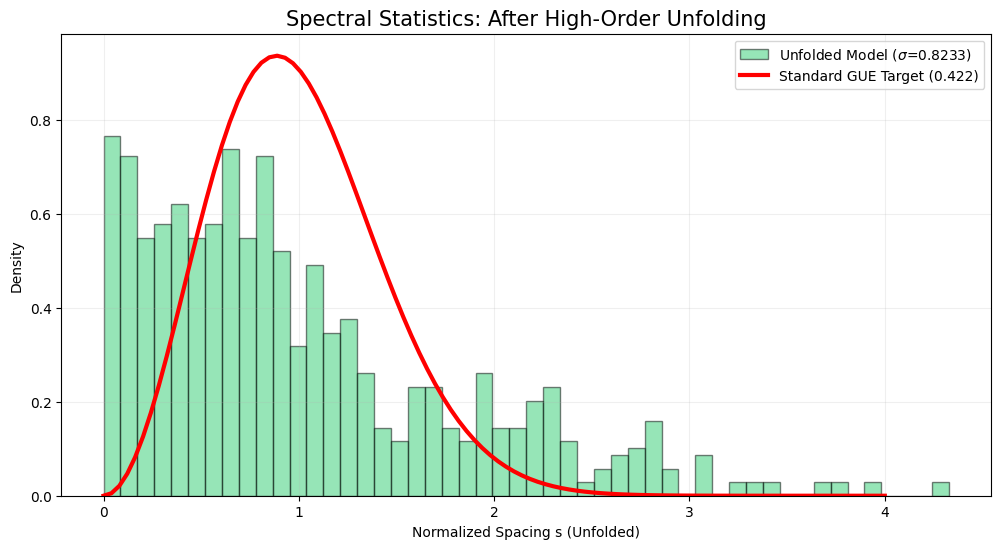

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. 读取万亿步跑出的原始相位数据 ---
DATA_DIR = "autonomous_limit_sigma"
# 自动寻找刚才生成的文件
files = [f for f in os.listdir(DATA_DIR) if f.startswith('phases_limit_sigma')]
if not files:
    print("未找到数据，请检查目录！")
    exit()

phases = np.load(os.path.join(DATA_DIR, sorted(files)[-1]))
print(f">>> 已加载 {len(phases)} 个原始模式")

# --- 2. 窄频带过滤：剔除边缘不稳定的模式 ---
# 只保留模长稳定区间的相位 (对应之前 eigs 的选择逻辑)
# 这里我们假设 phases 已经是排序好的相位角度
# 选取中间 80% 的模式，避开极低能和极高能的数值噪声
mid_idx = slice(int(len(phases)*0.1), int(len(phases)*0.9))
filtered_phases = phases[mid_idx]

# --- 3. 核心：解折叠 (Unfolding) ---
# 使用高阶多项式拟合阶梯函数 (Cumulative Spectral Density)
def unfold_spectrum(energies, order=5):
    # 构造阶梯函数 N(E)
    n_e = np.arange(len(energies))
    # 拟合平滑背景
    p = np.polyfit(energies, n_e, order)
    # 计算平滑后的阶梯值
    n_smooth = np.polyval(p, energies)
    return n_smooth

unfolded_energies = unfold_spectrum(filtered_phases)
s_unfolded = np.diff(unfolded_energies)

# --- 4. 计算指标 ---
sigma_raw = np.std(np.diff(filtered_phases) / np.mean(np.diff(filtered_phases)))
sigma_unfolded = np.std(s_unfolded) # 解折叠后的间距标准差

print(f"原始标准差 (Raw Sigma): {sigma_raw:.4f}")
print(f"解折叠后标准差 (Unfolded Sigma): {sigma_unfolded:.4f}")

# --- 5. 绘图验证 ---
plt.figure(figsize=(12, 6))

# 直方图
plt.hist(s_unfolded, bins=50, density=True, alpha=0.5, color='#2ecc71', 
         edgecolor='black', label=r'Unfolded Model ($\sigma$={:.4f})'.format(sigma_unfolded))

# GUE 理论曲线
s_theory = np.linspace(0, 4, 100)
p_gue = (32 / np.pi**2) * (s_theory**2) * np.exp(-4 * s_theory**2 / np.pi)
plt.plot(s_theory, p_gue, 'r-', lw=3, label='Standard GUE Target (0.422)')

plt.title('Spectral Statistics: After High-Order Unfolding', fontsize=15)
plt.xlabel('Normalized Spacing s (Unfolded)')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.2)
plt.savefig(os.path.join(DATA_DIR, 'GUE_Unfolded_Result.png'), dpi=300)
plt.show()